In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [25]:
df = pd.read_csv("/content/PM25_Hawaii_2022.csv.csv")
df.head()

,Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,Method Code,Method Description,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2022,AQS,150010005,1,2.2,ug/m3 LC,12,Hawaii Volcanoes NP - Kilauea Visitors Center,1,100.0,...,170,Met One BAM-1020 Mass Monitor w/VSCC,25900,"Hilo, HI",15,Hawaii,1,Hawaii,19.4308,-155.2578
1,01/02/2022,AQS,150010005,1,2.2,ug/m3 LC,12,Hawaii Volcanoes NP - Kilauea Visitors Center,1,100.0,...,707,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,25900,"Hilo, HI",15,Hawaii,1,Hawaii,19.4308,-155.2578
2,01/03/2022,AQS,150010005,1,2.0,ug/m3 LC,11,Hawaii Volcanoes NP - Kilauea Visitors Center,1,100.0,...,170,Met One BAM-1020 Mass Monitor w/VSCC,25900,"Hilo, HI",15,Hawaii,1,Hawaii,19.4308,-155.2578
3,01/04/2022,AQS,150010005,1,3.3,ug/m3 LC,18,Hawaii Volcanoes NP - Kilauea Visitors Center,1,100.0,...,170,Met One BAM-1020 Mass Monitor w/VSCC,25900,"Hilo, HI",15,Hawaii,1,Hawaii,19.4308,-155.2578
4,01/05/2022,AQS,150010005,1,3.0,ug/m3 LC,17,Hawaii Volcanoes NP - Kilauea Visitors Center,1,100.0,...,707,IMPROVE Module A with Cyclone Inlet-Teflon Fil...,25900,"Hilo, HI",15,Hawaii,1,Hawaii,19.4308,-155.2578


In [3]:
df.columns

Index(['Date', 'Source', 'Site ID', 'POC', 'Daily Mean PM2.5 Concentration',
       'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'Method Description', 'CBSA Code', 'CBSA Name',
       'State FIPS Code', 'State', 'County FIPS Code', 'County',
       'Site Latitude', 'Site Longitude'],
      dtype='object')

In [4]:
df.describe().round(2)

,Site ID,POC,Daily Mean PM2.5 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,6.024000e+03,6024.00,6024.00,6024.00,6024.0,6024.0,6024.00,6024.00,6024.00,6024.0,6024.00,6024.00,6024.00
mean,1.500259e+08,2.59,3.60,19.96,1.0,100.0,88112.52,258.80,32603.35,15.0,2.46,20.24,-156.45
std,2.360561e+04,4.53,1.95,10.59,0.0,0.0,66.98,150.01,9439.26,0.0,2.37,0.88,1.20
min,1.500100e+08,1.00,-1.50,0.00,1.0,100.0,88101.00,142.00,25900.00,15.0,1.00,19.06,-159.37
25%,1.500120e+08,1.00,2.30,13.00,1.0,100.0,88101.00,209.00,25900.00,15.0,1.00,19.51,-157.87
50%,1.500130e+08,1.00,3.30,18.00,1.0,100.0,88101.00,209.00,25900.00,15.0,1.00,19.72,-155.91
75%,1.500300e+08,2.00,4.60,26.00,1.0,100.0,88101.00,209.00,46520.00,15.0,3.00,21.31,-155.48
max,1.500990e+08,21.00,19.70,71.00,1.0,100.0,88502.00,738.00,46520.00,15.0,9.00,21.95,-155.06


In [5]:
df.info(verbose=True)
df.describe().round(1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6024 entries, 0 to 6023
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            6024 non-null   object 
 1   Source                          6024 non-null   object 
 2   Site ID                         6024 non-null   int64  
 3   POC                             6024 non-null   int64  
 4   Daily Mean PM2.5 Concentration  6024 non-null   float64
 5   Units                           6024 non-null   object 
 6   Daily AQI Value                 6024 non-null   int64  
 7   Local Site Name                 5990 non-null   object 
 8   Daily Obs Count                 6024 non-null   int64  
 9   Percent Complete                6024 non-null   float64
 10  AQS Parameter Code              6024 non-null   int64  
 11  AQS Parameter Description       6024 non-null   object 
 12  Method Code                     60

,Site ID,POC,Daily Mean PM2.5 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,6024.0,6024.0,6024.0,6024.0,6024.0,6024.0,6024.0,6024.0,6024.0,6024.0,6024.0,6024.0,6024.0
mean,150025937.8,2.6,3.6,20.0,1.0,100.0,88112.5,258.8,32603.3,15.0,2.5,20.2,-156.5
std,23605.6,4.5,2.0,10.6,0.0,0.0,67.0,150.0,9439.3,0.0,2.4,0.9,1.2
min,150010005.0,1.0,-1.5,0.0,1.0,100.0,88101.0,142.0,25900.0,15.0,1.0,19.1,-159.4
25%,150012016.0,1.0,2.3,13.0,1.0,100.0,88101.0,209.0,25900.0,15.0,1.0,19.5,-157.9
50%,150013027.0,1.0,3.3,18.0,1.0,100.0,88101.0,209.0,25900.0,15.0,1.0,19.7,-155.9
75%,150030010.0,2.0,4.6,26.0,1.0,100.0,88101.0,209.0,46520.0,15.0,3.0,21.3,-155.5
max,150099001.0,21.0,19.7,71.0,1.0,100.0,88502.0,738.0,46520.0,15.0,9.0,21.9,-155.1


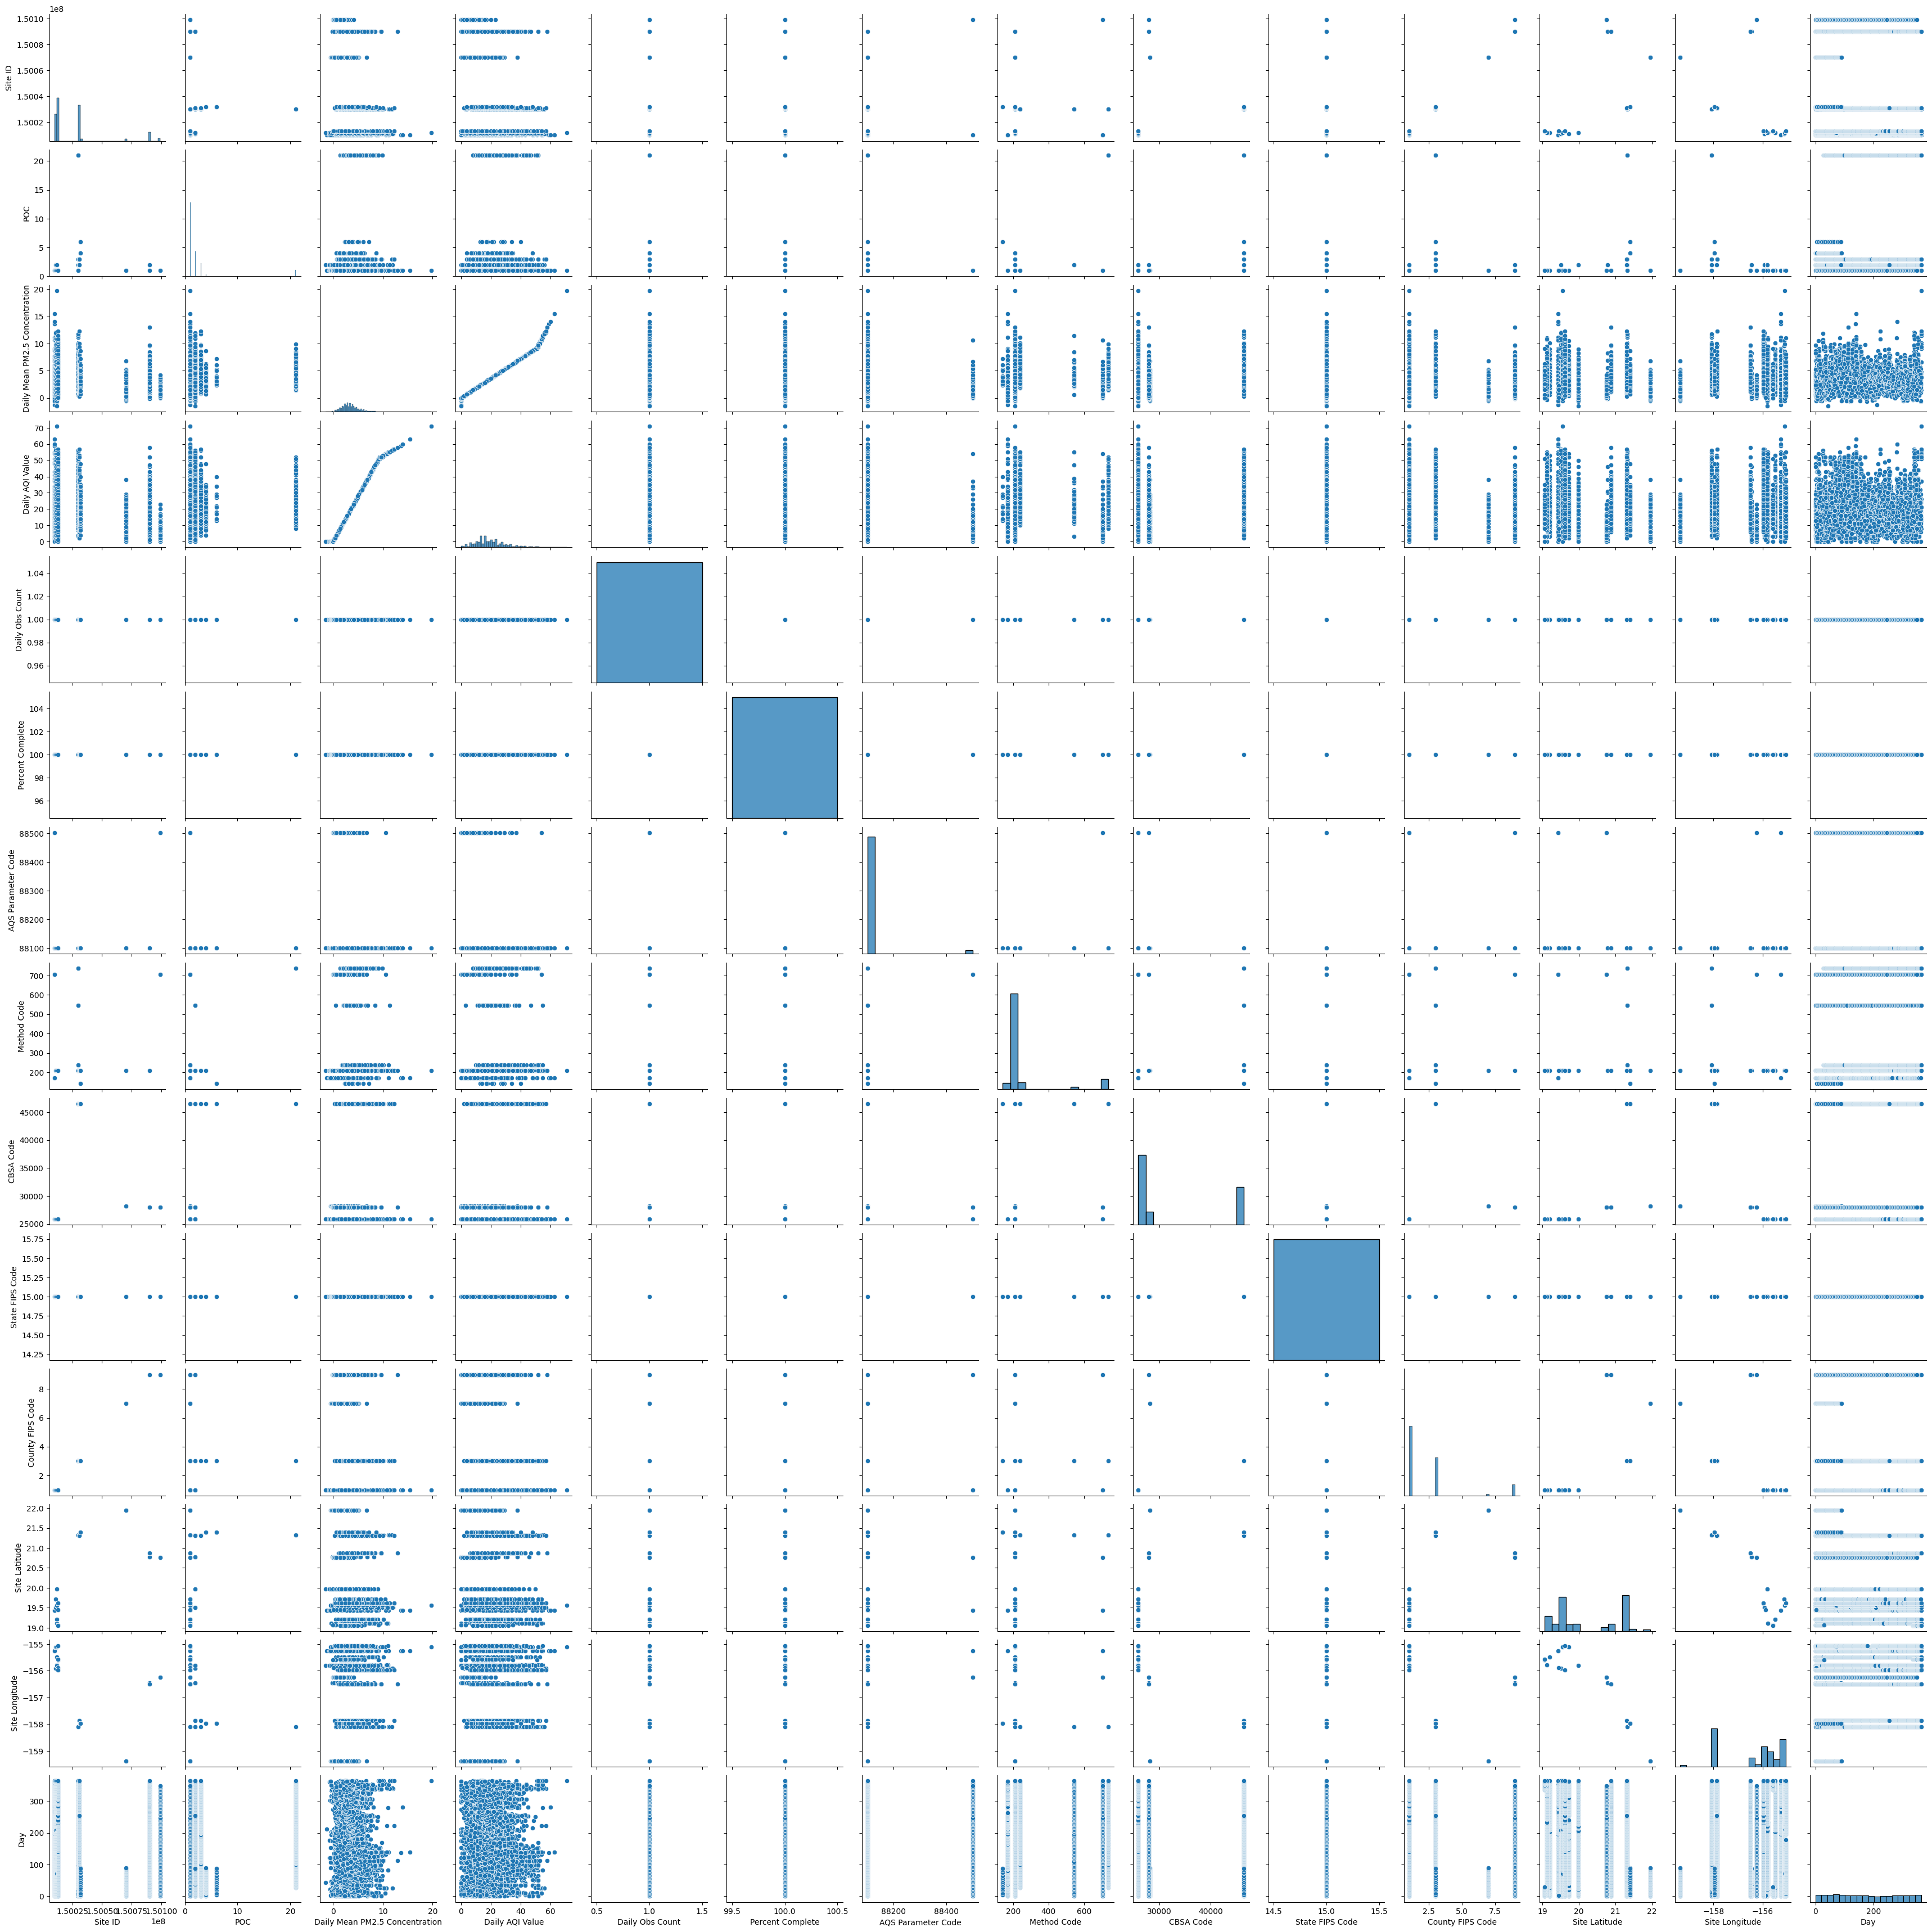

In [22]:
sns.pairplot(df)

<Axes: ylabel='Frequency'>

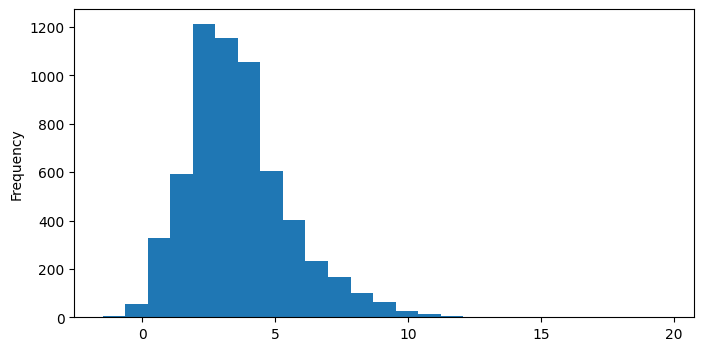

In [6]:
df["Daily Mean PM2.5 Concentration"].plot.hist(
    bins=25,
    figsize=(8,4)
)

<Axes: ylabel='Density'>

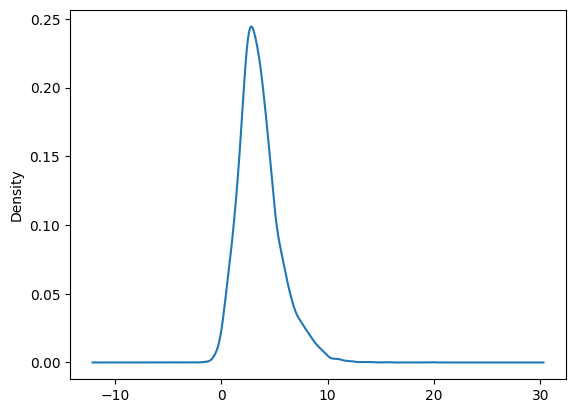

In [7]:
df["Daily Mean PM2.5 Concentration"].plot.density()

In [8]:
numeric_df = df.select_dtypes(include=[np.number])

numeric_df.corr().round(4)

,Site ID,POC,Daily Mean PM2.5 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
Site ID,1.0000,0.0514,-0.0779,-0.0785,NaN,NaN,0.3149,0.2258,0.1961,NaN,0.9980,0.5871,-0.4059
POC,0.0514,1.0000,0.0235,0.0246,NaN,NaN,-0.0603,0.7560,0.4559,NaN,0.0666,0.3832,-0.4190
Daily Mean PM2.5 Concentration,-0.0779,0.0235,1.0000,0.9966,NaN,NaN,-0.1836,-0.0629,0.0590,NaN,-0.0693,-0.0211,-0.0938
Daily AQI Value,-0.0785,0.0246,0.9966,1.0000,NaN,NaN,-0.1880,-0.0641,0.0613,NaN,-0.0697,-0.0198,-0.0973
Daily Obs Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Percent Complete,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AQS Parameter Code,0.3149,-0.0603,-0.1836,-0.1880,NaN,NaN,1.0000,0.5138,-0.0969,NaN,0.2803,0.0141,0.0768
Method Code,0.2258,0.7560,-0.0629,-0.0641,NaN,NaN,0.5138,1.0000,0.3222,NaN,0.2199,0.3244,-0.3099
CBSA Code,0.1961,0.4559,0.0590,0.0613,NaN,NaN,-0.0969,0.3222,1.0000,NaN,0.2199,0.8595,-0.8938
State FIPS Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

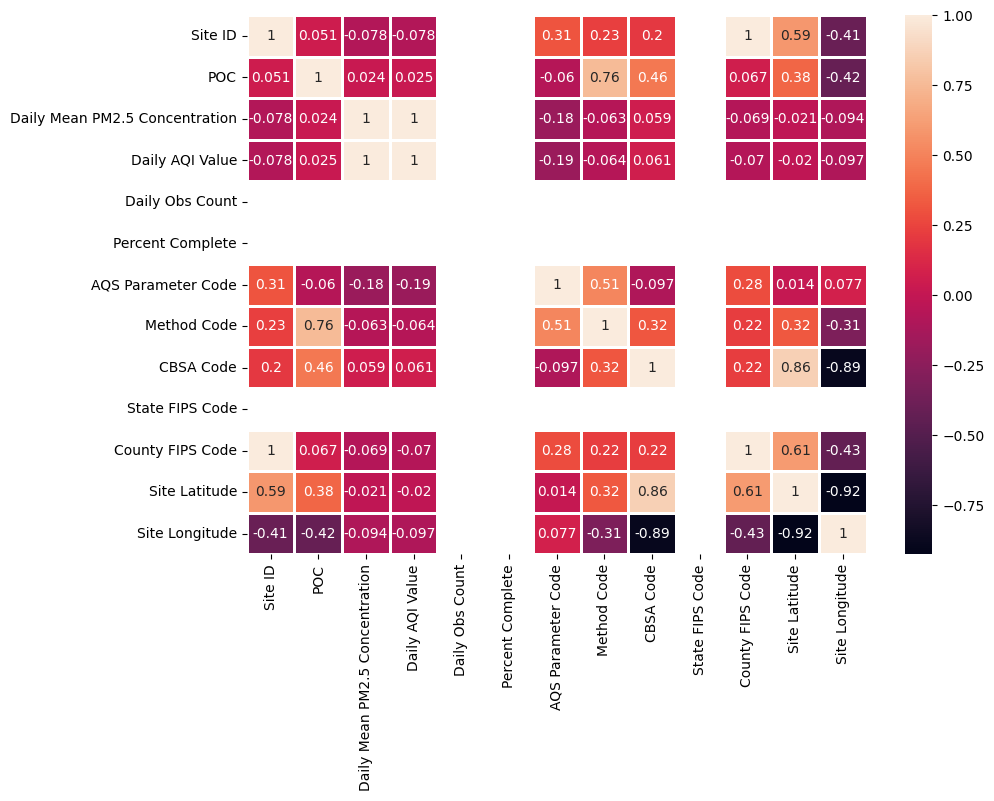

In [9]:
plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    linewidths=2
)

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

df["Day"] = (df["Date"] - df["Date"].min()).dt.days

In [11]:
x = df[["Day"]]

y = df["Daily Mean PM2.5 Concentration"]

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=123
)

In [13]:
from sklearn.linear_model import LinearRegression

from sklearn import metrics

lm = LinearRegression()

lm.fit(x_train, y_train)

LinearRegression()

In [14]:
print(
    "El termino de interseccion del modelo lineal:",
    lm.intercept_
)

print(
    "El coeficiente del modelo lineal:",
    lm.coef_
)

El termino de interseccion del modelo lineal: 3.923538878878892
El coeficiente del modelo lineal: [-0.00186482]


In [26]:
import statsmodels.api as sm

# Agregar constante para el intercepto
x_stats = sm.add_constant(x)

# Crear modelo OLS
modelo_stats = sm.OLS(y, x_stats)

# Ajustar modelo
resultado = modelo_stats.fit()

# Mostrar resumen estadístico
print(resultado.summary())

                                  OLS Regression Results                                  
Dep. Variable:     Daily Mean PM2.5 Concentration   R-squared:                       0.010
Model:                                        OLS   Adj. R-squared:                  0.009
Method:                             Least Squares   F-statistic:                     58.69
Date:                            Thu, 17 Sep 2026   Prob (F-statistic):           2.14e-14
Time:                                    21:05:59   Log-Likelihood:                -12549.
No. Observations:                            6024   AIC:                         2.510e+04
Df Residuals:                                6022   BIC:                         2.512e+04
Df Model:                                       1                                         
Covariance Type:                        nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------

In [15]:
cdf = pd.DataFrame(
    lm.coef_,
    x.columns,
    columns=["Coeficientes"]
)

cdf

,Coeficientes
Day,-0.001865


In [16]:
predictions = lm.predict(x)

print("Tipo del objeto predicho:", type(predictions))
print("Tamaño del objeto predicho:", predictions.shape)

Tipo del objeto predicho: <class 'numpy.ndarray'>
Tamaño del objeto predicho: (6024,)


In [27]:
from scipy.stats import shapiro

residuos = y - predictions

stat, p = shapiro(residuos)

print("Estadístico:", stat)
print("p-value:", p)

Estadístico: 0.9556042259195173
p-value: 2.2563196059080844e-39


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6024.
  res = hypotest_fun_out(*samples, **kwds)


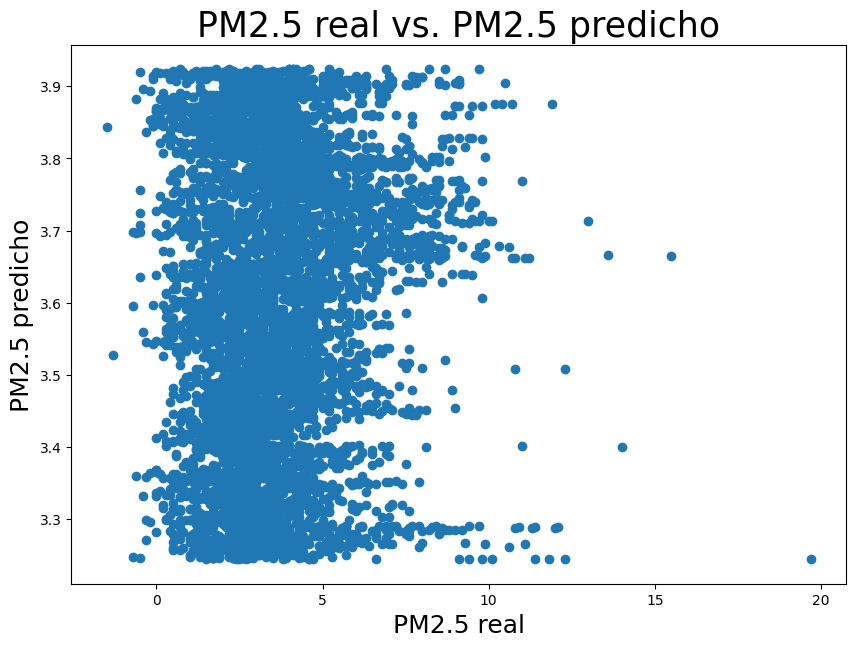

In [17]:
plt.figure(figsize=(10,7))

plt.title(
    "PM2.5 real vs. PM2.5 predicho",
    fontsize=25
)

plt.xlabel(
    "PM2.5 real",
    fontsize=18
)

plt.ylabel(
    "PM2.5 predicho",
    fontsize=18
)

plt.scatter(
    y,
    predictions
)

In [18]:
print(
    "Mean square error (MSE):",
    metrics.mean_squared_error(y, predictions)
)

print(
    "R²:",
    metrics.r2_score(y, predictions)
)

Mean square error (MSE): 3.7755141612738012
R²: 0.009607842359531493


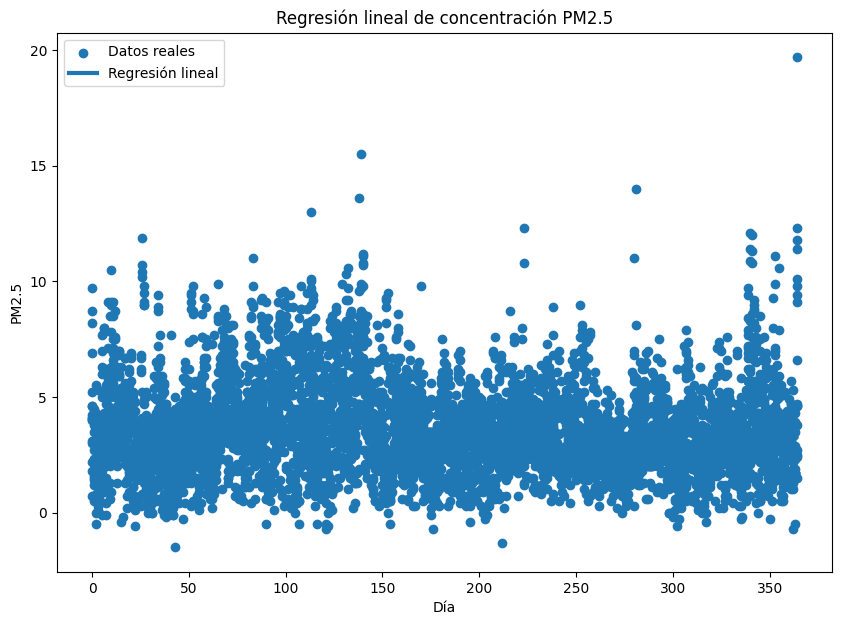

In [19]:
plt.figure(figsize=(10,7))

plt.scatter(
    x,
    y,
    label="Datos reales"
)

plt.plot(
    x,
    predictions,
    linewidth=3,
    label="Regresión lineal"
)

plt.xlabel("Día")
plt.ylabel("PM2.5")

plt.title(
    "Regresión lineal de concentración PM2.5"
)

plt.legend()

plt.show()

<Axes: title={'center': 'Histograma de residuos'}, xlabel='Residuos', ylabel='Densidad'>

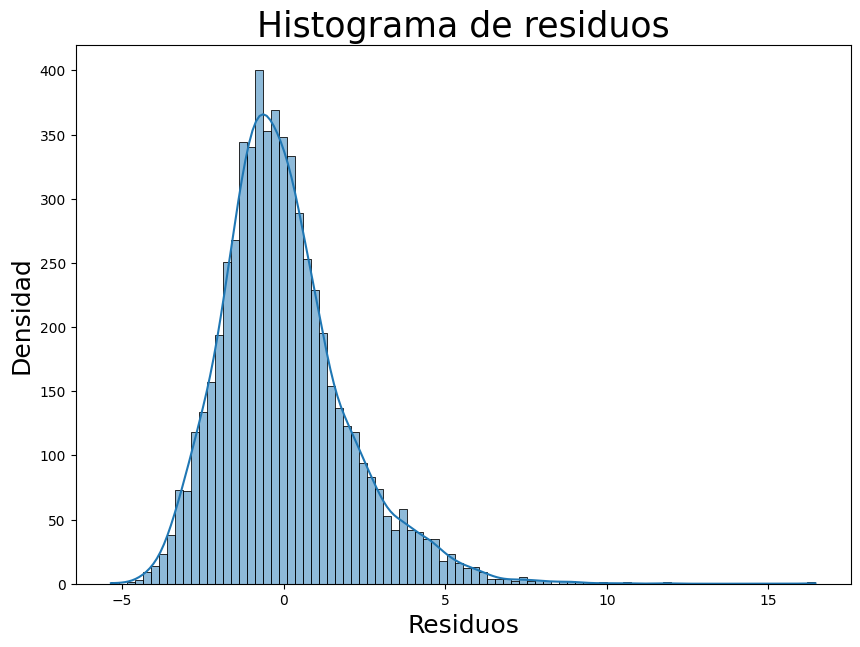

In [20]:
plt.figure(figsize=(10,7))

plt.title(
    "Histograma de residuos",
    fontsize=25
)

plt.xlabel(
    "Residuos",
    fontsize=18
)

plt.ylabel(
    "Densidad",
    fontsize=18
)

sns.histplot(
    (y - predictions),
    kde=True
)

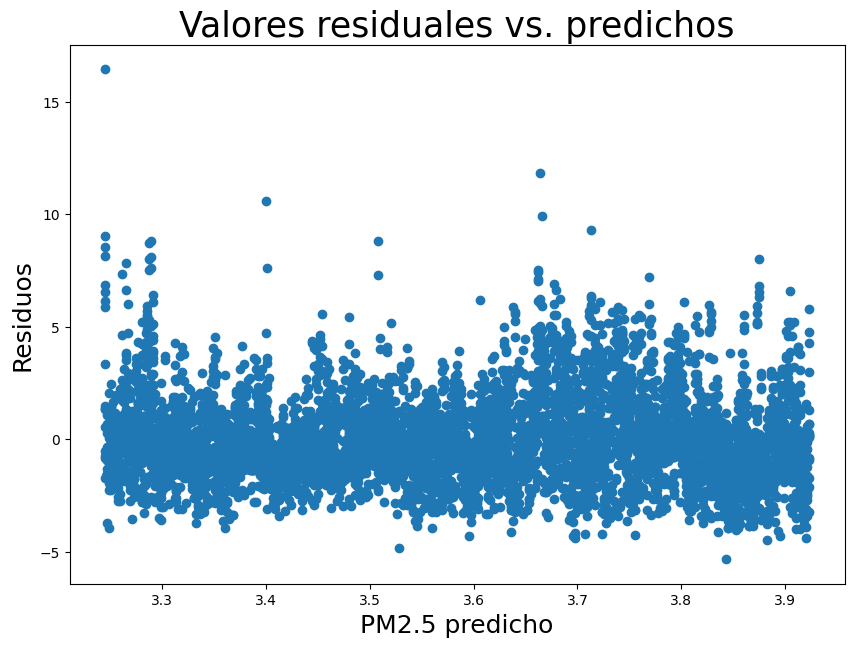

In [21]:
plt.figure(figsize=(10,7))

plt.title(
    "Valores residuales vs. predichos",
    fontsize=25
)

plt.xlabel(
    "PM2.5 predicho",
    fontsize=18
)

plt.ylabel(
    "Residuos",
    fontsize=18
)

plt.scatter(
    predictions,
    y - predictions
)